# Key metrics - DRG B

Sources:

See the "income and budget data" notebook for data assembly
- Municipal Fiscal indicators: https://data.ct.gov/browse?tags=2023+municipal+fiscal+indicators&sortBy=relevance&pageSize=20
- Equalized net grand list: https://portal.ct.gov/OPM/IGPP/IGPP-Home
- Municipal expenses by function https://data.ct.gov/Local-Government/Municipal-Fiscal-Indicators-Uniform-Chart-of-Accou/3gbm-qe5e/about_data
- Municipal Spending data: https://catalog.data.gov/dataset/uniform-chart-of-accounts-municipal-spending-data
- IRS tax return information by ZIP: https://www.irs.gov/statistics/soi-tax-stats-individual-income-tax-statistics-zip-code-data-soi
- OASDI (Social Security) by ZIP and year: https://www.ssa.gov/policy/docs/statcomps/oasdi_zip/2022/index.html

## Select peer group

Useful options include `peer', 'elite', 'aspirational', 'augmented', 'betters', 'peerplus', 'affordable', 'pca', 'finproj', 'finprojB', 'urban'`

In [1]:
# select peer group
PEERVAR = 'finprojB'
PEERVAL = 'DRG B'

In [2]:
import os.path as path
import os 
from os import mkdir
import re
from datetime import datetime
import numpy as np
from scipy import stats
import polars as pl
import pandas as pd
pd.options.display.html.use_mathjax = False

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Set the rcParam "text.usetex" to False
plt.rcParams["text.usetex"] = False

## Functions

In [3]:
# Define a custom formatter function

def dollar_i(x, pos):
    return f"${x:,.0f}"
    
def dollar_k(x, pos):
    return f"${int(x/1000):,}K"

# for when data is "in thousands"
def dollar_mm(x, pos):
    return f"${int(x/1000):,}MM"

# for when data is "in thousands"
def dollar_bb(x, pos):
    return f"${(x/1000000):,.1f}B"

# for when data is "in ones" - actual million
def dollar_realmm(x, pos):
    return f"${(x/1000000):,.1f}MM"
    
# for when data is "in ones" - actual billion
def dollar_realbb(x, pos):
    return f"${(x/1000000000):,.1f}B"
    
def comma(x, pos):
    return f"{int(x):,}"

def qty_k(x, pos):
    return f"{(x/1000):,.1f}K"

def percfmt(x, pos):
    return f"{x:.1%}"

def perc2fmt(x, pos):
    return f"{x:.2%}"
    
def percifmt(x, pos):
    return f"{x:.0%}"
    
# Apply the formatter to the y-axis
dollari_formatter = ticker.FuncFormatter(dollar_i)
dollar_k_formatter = ticker.FuncFormatter(dollar_k)
dollar_bb_formatter = ticker.FuncFormatter(dollar_bb)
dollar_realbb_formatter = ticker.FuncFormatter(dollar_realbb)
dollar_mm_formatter = ticker.FuncFormatter(dollar_mm)
dollar_realmm_formatter = ticker.FuncFormatter(dollar_realmm)
perc_formatter = ticker.FuncFormatter(percfmt)
perc2_formatter = ticker.FuncFormatter(perc2fmt)
perci_formatter = ticker.FuncFormatter(percifmt)

k_formatter = ticker.FuncFormatter(qty_k)
comma_formatter = ticker.FuncFormatter(comma)

In [4]:
# for plotting
rundate = datetime.now().strftime('%a %d %b %Y %H:%M:%S EDT')
software = f"Seaborn={sns.__version__}"

png_metadata = {
'Title': "Social Security Income",
'Author': 'Joel Danke',
'Description': "Based on OASDI data https://www.ssa.gov/policy/docs/statcomps/oasdi_zip/2022/index.html",
'Creation Time': rundate,
'Software': software}

## Import data
### File locations

In [5]:
# will split this into total & by-band rows
town_incomes = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_incomes.parquet')
town_ssi = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_ssi.parquet')
district_total_income = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/district_incomes.parquet')
district_accounts = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/district_chart_of_accounts.parquet')
accounts = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/town_chart_of_accounts.parquet')

In [6]:
#make directory if needed
try:
    mkdir(f"./charts/budget/{PEERVAR}")
except FileExistsError:
    pass

## Analysis
### Split to totals and band

In [7]:
town_band_income = town_incomes[town_incomes['Size of adjusted gross income'] != 'Total'].copy()
town_total_income = town_incomes[town_incomes['Size of adjusted gross income'] == 'Total'].copy()

### Granby Key Stats
Per Taxpayer is from IRS data using counts of returns filed jointly, single, or head of household. Married couples double the number shown.

In [8]:
# key stats
qty = ['Number of returns', 'Number of elderly returns', 'Taxpayers', 'Number of individuals', 'Average School Enrollment']
perc = [ 'Education Share Of Income', 'Taxes Share Of Income', 'Education Share Of Budget', 'Debt Service Share Of Budget']
dolr = ['Income Per Taxpayer (2024 dollars)', 'Flat Tax Per Taxpayer (2024 dollars)']
key_stats = ['Year'] +  qty + dolr + perc 
town_total_income.query('Town == "Granby"')[key_stats]\
    .style.format({x:"{:,.0f}" for x in qty} | {x: "{:.1%}" for x in perc} | {x : "${:,.0f}" for x in dolr})

,Year,Number of returns,Number of elderly returns,Taxpayers,Number of individuals,Average School Enrollment,Income Per Taxpayer (2024 dollars),Flat Tax Per Taxpayer (2024 dollars),Education Share Of Income,Taxes Share Of Income,Education Share Of Budget,Debt Service Share Of Budget
4248,2013,"5,520",0,"8,250",0,"2,024","$88,733","$5,195",5.4%,5.9%,70.7%,8.0%
4255,2014,"5,480",0,"8,220",0,"1,948","$91,408","$5,318",5.3%,5.8%,70.3%,7.7%
4262,2015,"5,520","1,640","8,240",0,"1,921","$94,476","$5,425",5.1%,5.8%,69.9%,8.4%
4269,2016,"5,480","1,660","8,200",0,"1,836","$90,813","$5,508",5.7%,6.1%,70.9%,7.6%
4276,2017,"5,520","1,730","8,230",0,"1,827","$92,515","$5,492",5.7%,6.0%,71.7%,7.3%
4283,2018,"5,530","1,820","8,250","10,790","1,833","$97,787","$5,652",4.9%,5.8%,69.9%,7.4%
4290,2019,"5,660","1,880","8,400","10,870","1,759","$94,155","$5,683",5.2%,6.1%,71.9%,5.8%
4297,2020,"5,760","1,940","8,470","10,920","1,694","$93,583","$5,645",5.4%,6.1%,72.3%,4.4%
4304,2021,"5,700","2,000","8,380","10,780","1,725","$103,691","$5,470",4.8%,5.3%,70.8%,3.5%
4311,2022,"5,790","2,080","8,500","10,950","1,690","$96,726","$5,211",5.1%,5.4%,74.0%,3.7%


### School District Comparisons

#### First in general

### Select peer group
From district-level data

In [9]:
# get data
district_band_income = district_total_income[district_total_income['Size of adjusted gross income'] != 'Total'].copy()
district_total_income = district_total_income[district_total_income['Size of adjusted gross income'] == 'Total'].copy()

# limit to peers
district_total_income = district_total_income[(district_total_income[PEERVAR] > 0)]
district_total_income = district_total_income[district_total_income['Fiscal Year End'] > 2014]
district_total_income = district_total_income[~district_total_income['District'].str.startswith('Greenw')]
#district_total_income = district_total_income[district_total_income['Fiscal Year End']

# for plotting
district_total_income['Granby'] = (district_total_income[PEERVAR] == 2).astype('int')
district_total_income[PEERVAR] = district_total_income[PEERVAR]\
                                .where(~district_total_income['District'].str.startswith('Region'), 3)

district_total_income.sort_values(by=['Year', PEERVAR, 'Granby'], inplace=True)

#### Color scheme

In [10]:
# color scheme
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in district_total_income['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

peer_cols = {3: (0.19, 0.27, 0.57, .4),
             2: 'black',
             1: (0.529, 0.808, 0.922, .4)}

flag_cols = {0:(0.69, 0.77, 0.87, .4), 1:'black'}

In [11]:
# show districts in peer group
print(f"Using peer variable: {PEERVAR}\n")
for d in sorted(district_total_income[district_total_income[PEERVAR] > 0].District.unique()):
    print(d)

Using peer variable: finprojB

Avon School District
Brookfield School District
Canton School District
Cheshire School District
Fairfield School District
Farmington School District
Glastonbury School District
Granby School District
Guilford School District
Monroe School District
Oxford School District
Regional School District 15
Rocky Hill School District
Simsbury School District
South Windsor School District
Trumbull School District
West Hartford School District


In [12]:
_df = district_total_income[district_total_income['Fiscal Year End'] == 2022]\
    [['District', 'Total income Amount', 'Real Income Per Taxpayer', 'Equalized Net Grand List MM',
      '% Age 65+', '% HH w/Children', 'Enrollment Rate', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']]\
    .rename(columns={'Equalized Net Grand List MM': 'EQ Grand List'}).copy().sort_values('Real Income Per Taxpayer')

_df['District Income'] = _df["Total income Amount"]/1000
_df['EQ Grand List'] = _df['EQ Grand List']/1000
_df[['District', 'District Income', 'EQ Grand List', 'Real Income Per Taxpayer', '% Age 65+', 'Enrollment Rate', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']]\
    .style.format({"District Income": "${:,.0f} B", "EQ Grand List": "${:,.2f} B", "Real Income Per Taxpayer": "${:,.0f}"} |
                  {'Enrollment Rate': "{:.1%}"} |
                  {x: "{:.0f}%" for x in ['% Age 65+', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']})\
    .set_caption("District Comparison - Latest Available Data (2022) Not Adjusted For Inflation")\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])\
    .hide(axis="index")

District,District Income,EQ Grand List,Real Income Per Taxpayer,% Age 65+,Enrollment Rate,% Owner Occ,% SNAP,% w/Bachelors+,% Management
Rocky Hill School District,"$1,083 B",$3.77 B,"$66,003",36%,12.9%,66%,5%,48%,52%
Oxford School District,$798 B,$2.41 B,"$71,081",36%,13.6%,92%,3%,46%,51%
South Windsor School District,"$1,573 B",$5.13 B,"$72,143",33%,18.3%,84%,4%,56%,60%
Monroe School District,"$1,185 B",$3.68 B,"$76,103",33%,18.0%,93%,2%,55%,59%
Trumbull School District,"$2,410 B",$8.29 B,"$81,527",34%,18.2%,89%,3%,60%,58%
Canton School District,$660 B,$1.74 B,"$82,203",38%,15.0%,83%,3%,57%,54%
Brookfield School District,"$1,191 B",$3.96 B,"$82,380",38%,15.1%,85%,2%,51%,49%
Granby School District,$780 B,$1.76 B,"$82,967",34%,15.6%,91%,3%,56%,53%
Cheshire School District,"$1,872 B",$5.06 B,"$83,358",35%,14.3%,88%,3%,62%,64%
Regional School District 15,"$2,151 B",$5.58 B,"$93,921",49%,12.9%,87%,6%,53%,57%


In [13]:
_df = district_total_income[district_total_income['Fiscal Year End'] == 2022]\
    [['District', 'Total Income (2024 dollars)', 'Income Per Taxpayer (2024 dollars)', 'Equalized Net Grand List MM (2024 dollars)',
      '% Age 65+', '% HH w/Children', 'Enrollment Rate', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']]\
    .copy().sort_values('Income Per Taxpayer (2024 dollars)')

_df['District Income (2024 dollars)'] = _df["Total Income (2024 dollars)"]/1000000
_df['EQ Grand List (2024 dollars)'] = _df['Equalized Net Grand List MM (2024 dollars)']/1000

_df[['District', 'District Income (2024 dollars)', 'EQ Grand List (2024 dollars)', 'Income Per Taxpayer (2024 dollars)', '% Age 65+', 'Enrollment Rate', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']]\
    .style.format({"District Income (2024 dollars)": "${:,.0f} B", "EQ Grand List (2024 dollars)": "${:,.2f} B", "Income Per Taxpayer (2024 dollars)": "${:,.0f}"} |
                  {'Enrollment Rate': "{:.1%}"} |
                  {x: "{:.0f}%" for x in ['% Age 65+', '% Owner Occ', '% SNAP', '% w/Bachelors+', '% Management']})\
    .set_caption("District Comparison - Latest Available Data (2022) Inflation-Adjusted To 2024 Dollars")\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])\
    .hide(axis="index")

District,District Income (2024 dollars),EQ Grand List (2024 dollars),Income Per Taxpayer (2024 dollars),% Age 65+,Enrollment Rate,% Owner Occ,% SNAP,% w/Bachelors+,% Management
Rocky Hill School District,"$1,206 B",$4.20 B,"$82,490",36%,12.9%,66%,5%,48%,52%
Oxford School District,$889 B,$2.68 B,"$88,837",36%,13.6%,92%,3%,46%,51%
South Windsor School District,"$1,752 B",$5.72 B,"$90,164",33%,18.3%,84%,4%,56%,60%
Monroe School District,"$1,320 B",$4.10 B,"$95,112",33%,18.0%,93%,2%,55%,59%
Trumbull School District,"$2,685 B",$9.23 B,"$101,891",34%,18.2%,89%,3%,60%,58%
Canton School District,$736 B,$1.94 B,"$102,736",38%,15.0%,83%,3%,57%,54%
Brookfield School District,"$1,327 B",$4.41 B,"$102,957",38%,15.1%,85%,2%,51%,49%
Granby School District,$869 B,$1.97 B,"$103,691",34%,15.6%,91%,3%,56%,53%
Cheshire School District,"$2,086 B",$5.64 B,"$104,180",35%,14.3%,88%,3%,62%,64%
Regional School District 15,"$2,396 B",$6.22 B,"$117,382",49%,12.9%,87%,6%,53%,57%


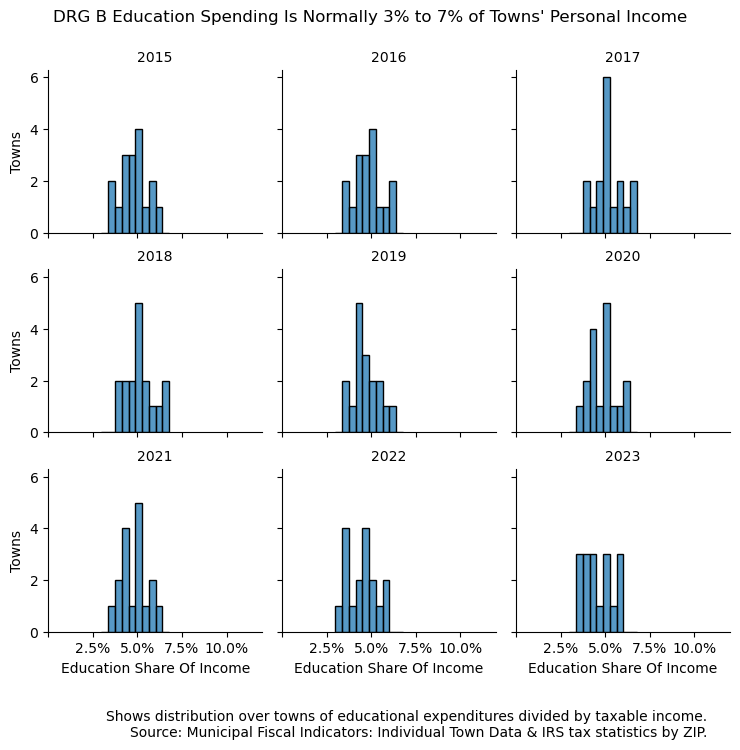

In [14]:
g = sns.displot(data=district_total_income[district_total_income['Fiscal Year End'] >= 2015], x='Education Share Of Income',
            col='Fiscal Year End', col_wrap=3, height=2.5)

g.fig.suptitle(f"{PEERVAL} Education Spending Is Normally 3% to 7% of Towns' Personal Income")

g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    ax.set_ylabel('Towns')
    ax.set_xlim(0,0.12)
    ax.xaxis.set_major_formatter(perc_formatter)
    labels = ax.xaxis.get_ticklabels()
    if len(labels) > 0:
        labels[0].set_visible(False)
        labels[-1].set_visible(False)

plt.subplots_adjust(top=.9, bottom=0.15)

line1 = "Shows distribution over towns of educational expenditures divided by taxable income.\n"
line2 = "Source: Municipal Fiscal Indicators: Individual Town Data & IRS tax statistics by ZIP."
g.fig.text(.95, .01, line1+line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/education_share_of_income.png", dpi=200, metadata=png_metadata)

plt.show()

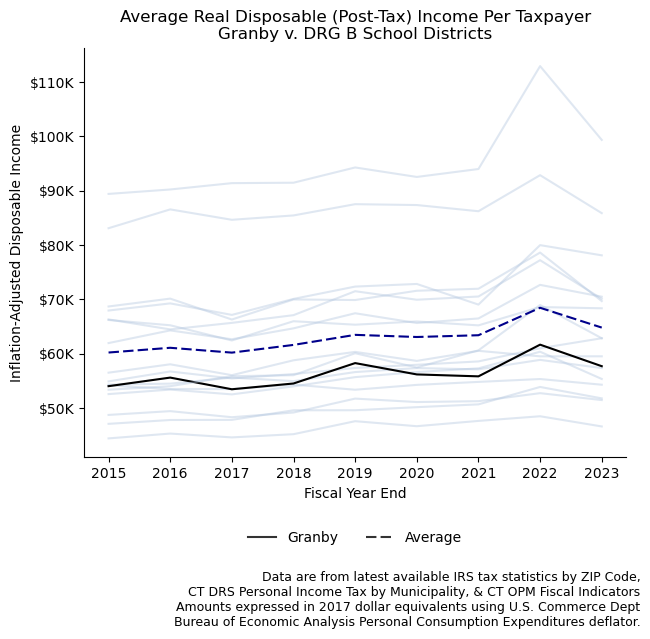

In [15]:
_ave = pd.DataFrame(district_total_income.groupby('Fiscal Year End')['Real Disposable Income Per Taxpayer'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'

tmpdf = pd.concat([district_total_income, _ave], axis=0, ignore_index=True)
tmpdf['Granby'] = 'Other'
tmpdf['Granby'] = tmpdf['Granby'].where(~tmpdf['District'].str.startswith('Granby'), 'Granby')
tmpdf['Granby'] = tmpdf['Granby'].where(~tmpdf['District'].str.startswith('Average'), 'Average')

fig, g = plt.subplots(1, 1, figsize=(7,6.5))
sns.lineplot(data=tmpdf,
                y='Real Disposable Income Per Taxpayer', 
                x='Fiscal Year End', hue='District',
                style='Granby', dashes=[(None, None), (None, None), (5, 2)],
                 ax=g,
                palette=school_cols)
sns.despine()
g.set_title(f'Average Real Disposable (Post-Tax) Income Per Taxpayer\nGranby v. {PEERVAL} School Districts')
g.set_ylabel('Inflation-Adjusted Disposable Income')
g.yaxis.set_major_formatter(dollar_k_formatter)
g.legend()

h, lab = g.get_legend_handles_labels()
g.legend(h[-2:], lab[-2:])
sns.move_legend(g, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncols=2, frameon=False)


plt.subplots_adjust(top=.9, bottom=0.27)

line3 = "Amounts expressed in 2017 dollar equivalents using U.S. Commerce Dept\n"
line4 = "Bureau of Economic Analysis Personal Consumption Expenditures deflator."
line1 = "Data are from latest available IRS tax statistics by ZIP Code,\n"
line2 = "CT DRS Personal Income Tax by Municipality, & CT OPM Fiscal Indicators\n"
fig.text(.92, .01, line1 + line2 + line3 + line4, ha='right', fontsize=9)

plt.savefig(f"./charts/budget/{PEERVAR}/peer_real_disposable_income.png", dpi=200, metadata=png_metadata)

plt.show()

### Relative to incomes

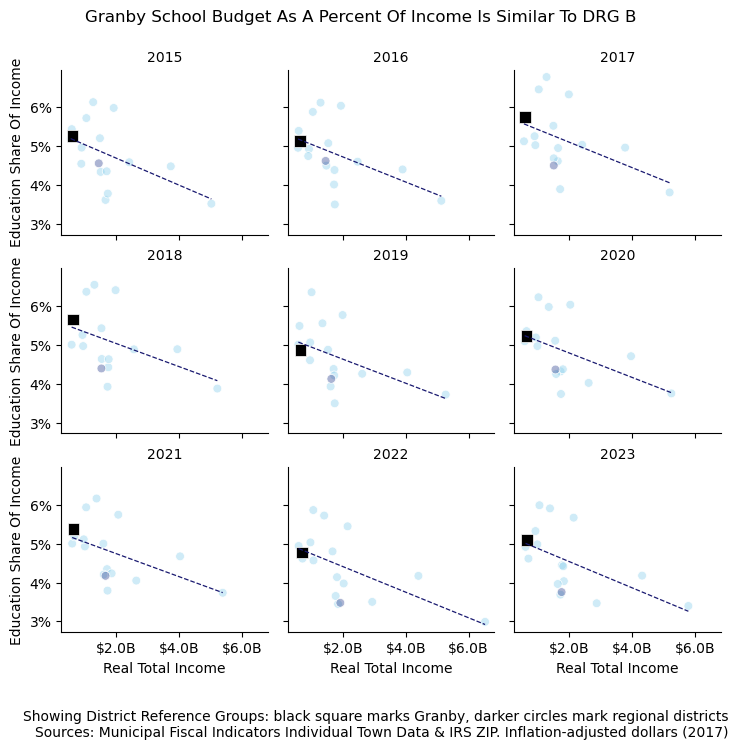

In [16]:
g = sns.relplot(data=district_total_income,
                col='Fiscal Year End', col_wrap=3,
                x='Real Total Income', y='Education Share Of Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real Total Income', y='Education Share Of Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    #plt.xscale('log') 

g.fig.suptitle(f"Granby School Budget As A Percent Of Income Is Similar To {PEERVAL}")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Inflation-adjusted dollars (2017)"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/ed_income_share_v_total_income.png", dpi=200, metadata=png_metadata)

plt.show()

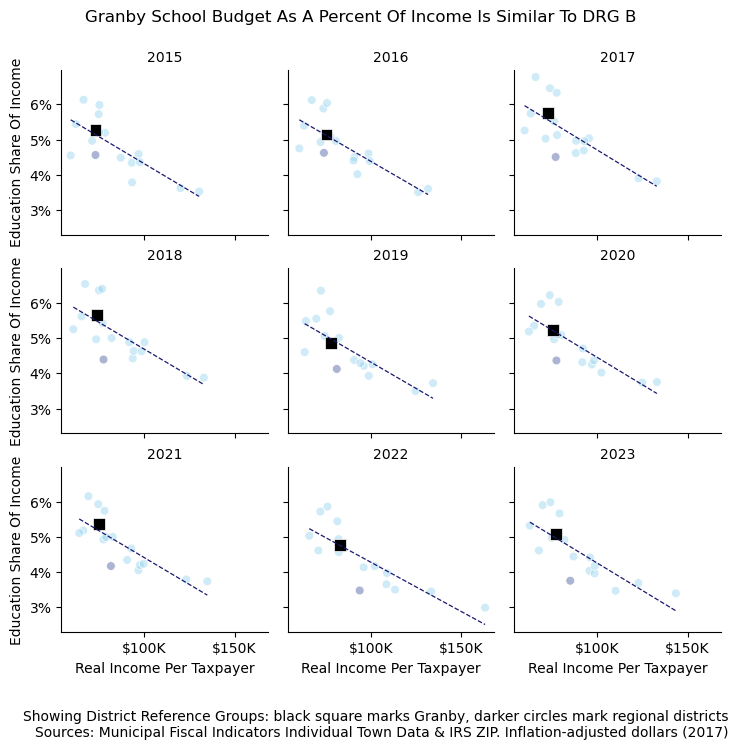

In [17]:
g = sns.relplot(data=district_total_income,
                col='Fiscal Year End', col_wrap=3,
                x='Real Income Per Taxpayer', y='Education Share Of Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real Income Per Taxpayer', y='Education Share Of Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    #plt.xscale('log') 

g.fig.suptitle(f"Granby School Budget As A Percent Of Income Is Similar To {PEERVAL}")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Inflation-adjusted dollars (2017)"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/ed_income_share_v_ave_income.png", dpi=200, metadata=png_metadata)

plt.show()

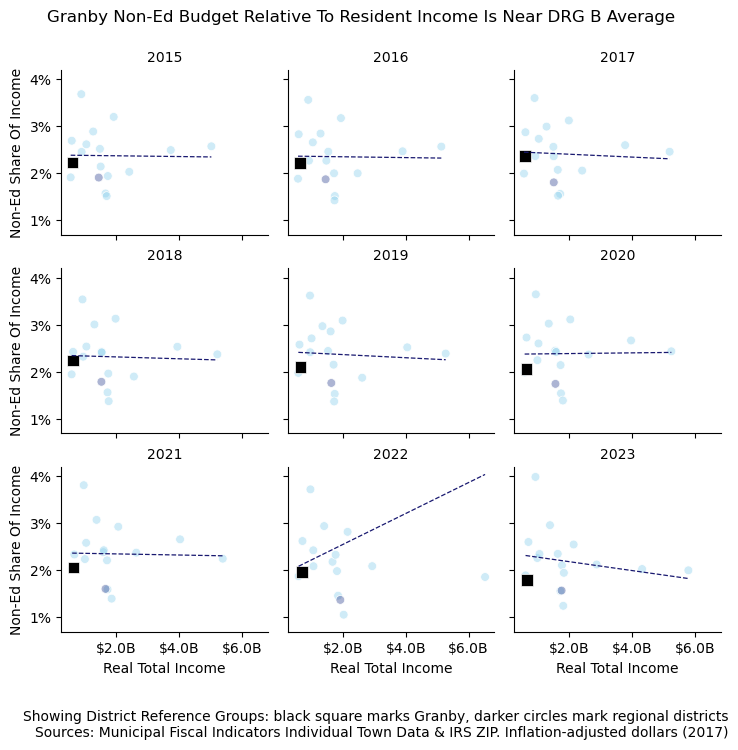

In [18]:
g = sns.relplot(data=district_total_income.rename(columns={'Non-Education Share Of Income': 'Non-Ed Share Of Income'}),
                col='Fiscal Year End', col_wrap=3,
                x='Real Total Income', y='Non-Ed Share Of Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real Total Income', y='Non-Ed Share Of Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.set_ylim(top=.042)
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_realbb_formatter)
    #plt.xscale('log') 

g.fig.suptitle(f"Granby Non-Ed Budget Relative To Resident Income Is Near {PEERVAL} Average")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Inflation-adjusted dollars (2017)"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/noned_income_share_v_total_income.png", dpi=200, metadata=png_metadata)

plt.show()

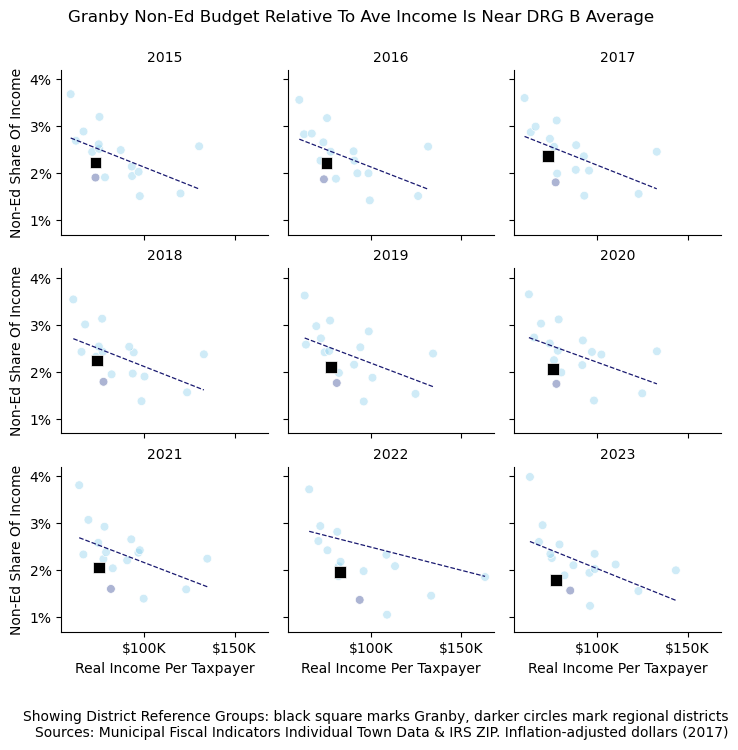

In [19]:
g = sns.relplot(data=district_total_income.rename(columns={'Non-Education Share Of Income': 'Non-Ed Share Of Income'}),
                col='Fiscal Year End', col_wrap=3,
                x='Real Income Per Taxpayer', y='Non-Ed Share Of Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Real Income Per Taxpayer', y='Non-Ed Share Of Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.set_ylim(top=.042)
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    #plt.xscale('log') 

g.fig.suptitle(f"Granby Non-Ed Budget Relative To Ave Income Is Near {PEERVAL} Average")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Inflation-adjusted dollars (2017)"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/noned_income_share_v_ave_income.png", dpi=200, metadata=png_metadata)
plt.show()

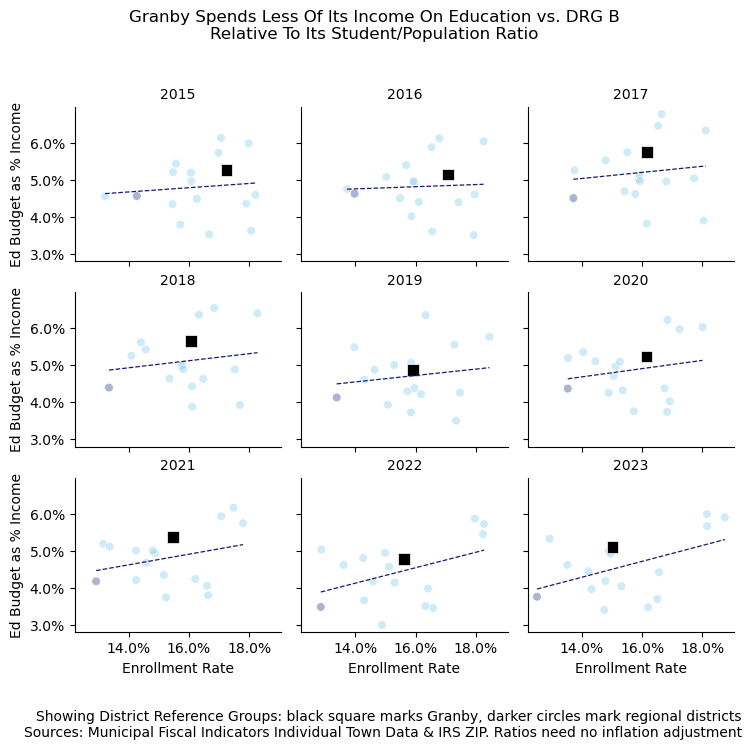

In [20]:
g = sns.relplot(data=district_total_income.rename(columns={'Education Share Of Income': 'Ed Budget as % Income'}),
                col='Fiscal Year End', col_wrap=3,
                x='Enrollment Rate', y='Ed Budget as % Income', 
                height=2.5,  legend=None,
                hue = PEERVAR, palette=peer_cols,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],)

g.set_titles(col_template="{col_name}")

g.map_dataframe(sns.regplot, x='Enrollment Rate', y='Ed Budget as % Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(perc_formatter)
    ax.yaxis.set_major_formatter(perc_formatter)

g.fig.suptitle(f"Granby Spends Less Of Its Income On Education vs. {PEERVAL}\nRelative To Its Student/Population Ratio")

plt.subplots_adjust(top=.85, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Sources: Municipal Fiscal Indicators Individual Town Data & IRS ZIP. Ratios need no inflation adjustment"
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/ed_income_share_v_studentperc.png", dpi=200, metadata=png_metadata)
plt.show()

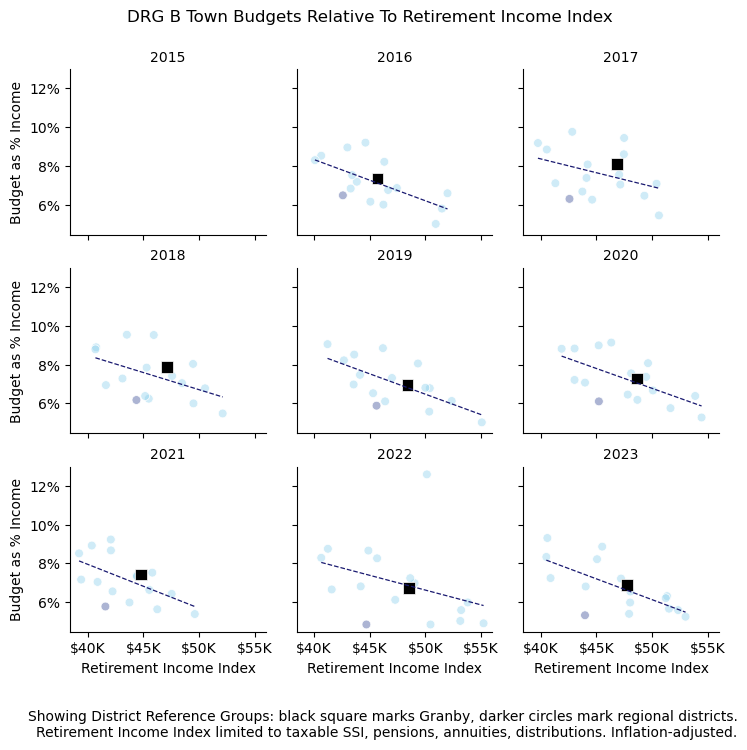

In [21]:
g = sns.relplot(data=district_total_income.rename(columns={'Budget Share Of Income': 'Budget as % Income'}),
                col='Fiscal Year End', col_wrap=3,
                x='Retirement Income Index', y='Budget as % Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Retirement Income Index', y='Budget as % Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    #plt.xscale('log') 

g.fig.suptitle(f"{PEERVAL} Town Budgets Relative To Retirement Income Index")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts.\n"
line2 = "Retirement Income Index limited to taxable SSI, pensions, annuities, distributions. Inflation-adjusted."
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/budget_income_share_v_retirementindex.png", dpi=200, metadata=png_metadata)

plt.show()

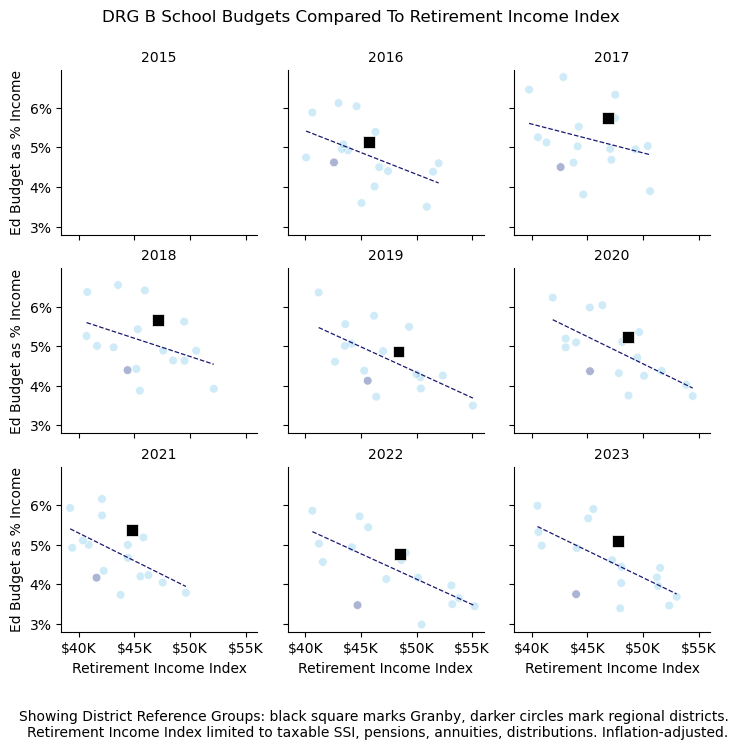

In [22]:
g = sns.relplot(data=district_total_income.rename(columns={'Education Share Of Income': 'Ed Budget as % Income'}),
                col='Fiscal Year End', col_wrap=3,
                x='Retirement Income Index', y='Ed Budget as % Income',
                height=2.5, palette=peer_cols, legend=None,
                style='Granby', markers=['o','s'],
                size='Granby', sizes=[40, 72],
                hue = PEERVAR,)

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Retirement Income Index', y='Ed Budget as % Income', scatter=False, ci=None,
               line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(dollar_k_formatter)
    #plt.xscale('log') 

g.fig.suptitle(f"{PEERVAL} School Budgets Compared To Retirement Income Index")

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts.\n"
line2 = "Retirement Income Index limited to taxable SSI, pensions, annuities, distributions. Inflation-adjusted."
g.fig.text(.99, .01, line1 + line2, ha='right')

plt.savefig(f"./charts/budget/{PEERVAR}/edbudget_income_share_v_retirementindex.png", dpi=200, metadata=png_metadata)

plt.show()

In [23]:
district_total_income[district_total_income['Education Share Of Income'] < .025]

,District,Year,Fiscal Year End,Size of adjusted gross income,Number of returns,Number of single returns,Number of joint returns,Number of head of household returns,Number of exemptions,Number of dependents,...,Flat Tax Per Single Taxpayer,Real Flat Tax Per Taxpayer,Flat Tax Per Taxpayer (2024 dollars),Retirement Income Per Return,Retirement Income Index,Retirement Income Index (2024 dollars),Average School Enrollment,Population,Enrollment Rate,Granby


### Are Retirees 'Getting Squeezed'?

### Income by AGI Band

#### Break out totals & income bands

In [24]:
granby_incomes = town_incomes[(town_incomes['Town'] == 'Granby') &\
                              (town_incomes['Size of adjusted gross income'] != 'Total')].copy()
granby_incomes['Income Band'] = granby_incomes['Income Band'].cat.remove_unused_categories()
granby_incomes['Number of Non-Elderly Returns'] = (granby_incomes['Number of returns']
                                       - granby_incomes['Number of elderly returns'].replace(0, np.nan))
granby_incomes['Elderly Share of Returns'] = granby_incomes['Number of elderly returns'] / granby_incomes['Number of returns']
granby_incomes['Share Of Returns'] = granby_incomes['Number of returns'] / granby_incomes.groupby('Year')['Number of returns'].transform('sum')

In [25]:
# % of elderly in each band
ttl_elderly = granby_incomes.groupby('Year')['Number of elderly returns'].sum()
ttl_elderly.name = 'total elderly returns'
ttl_elderly = pd.DataFrame(ttl_elderly).reset_index(drop=False)
granby_incomes = granby_incomes.merge(ttl_elderly, on='Year', how='left')
granby_incomes['Share of Elderly Returns'] = granby_incomes['Number of elderly returns']/granby_incomes['total elderly returns']

In [26]:
# % of non-elderly in each band
ttl_non_elderly = granby_incomes.groupby('Year')['Number of Non-Elderly Returns'].sum()
ttl_non_elderly.name = 'total nonelderly returns'
ttl_non_elderly = pd.DataFrame(ttl_non_elderly).reset_index(drop=False)
granby_incomes = granby_incomes.merge(ttl_non_elderly, on='Year', how='left')
granby_incomes['Share of Non-Elderly Returns'] = granby_incomes['Number of Non-Elderly Returns']/granby_incomes['total nonelderly returns']

### Income Tables
Source: IRS tax information by ZIP
Per taxpayer counts 2 for married filing jointly, 1 for single & head-of-household returns. Each return counts as a household.

**

In [27]:
cap1 = "Average Taxable Income Per Household (Inflation-Adjusted 2024 dollars)"
granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Income Per Return (2024 dollars)')\
              .style.format("${:,.0f}")\
    .set_caption(cap1)\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000","$13,378","$13,293","$12,926","$13,185","$22,746","$12,900","$12,606","$11,779"
"\$25,000 under \$50,000","$48,390","$47,828","$47,267","$45,682","$45,382","$44,357","$68,111","$39,655"
"\$50,000 under \$75,000","$81,228","$80,282","$78,799","$76,028","$74,409","$73,353","$70,409","$66,900"
"\$75,000 under \$100,000","$114,534","$110,967","$108,848","$107,978","$177,047","$104,399","$168,827","$92,128"
"\$100,000 under \$200,000","$181,898","$180,501","$176,882","$174,521","$171,940","$169,163","$160,302","$152,400"
"\$200,000 or more","$511,165","$469,188","$461,351","$488,166","$451,038","$452,379","$490,256","$434,666"


In [28]:
#  returns in each band
_dist = granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Number of returns')
_dist.style.format("{:,.0f}").set_caption('Number of Tax Returns In Each Band')\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000","1,380","1,340","1,290","1,230","1,210","1,180","1,070","1,100"
"\$25,000 under \$50,000",740,750,730,740,780,820,790,770
"\$50,000 under \$75,000",700,660,700,690,740,800,710,690
"\$75,000 under \$100,000",610,610,620,620,640,650,650,650
"\$100,000 under \$200,000","1,430","1,470","1,470","1,470","1,490","1,520","1,540","1,590"
"\$200,000 or more",660,650,710,780,800,790,940,990


In [29]:
#  returns in each band
_dist = granby_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Share Of Returns')
_dist.style.format("{:,.1%}").set_caption('Share of Tax Returns In Each Band')\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",25.0%,24.5%,23.4%,22.2%,21.4%,20.5%,18.8%,19.0%
"\$25,000 under \$50,000",13.4%,13.7%,13.2%,13.4%,13.8%,14.2%,13.9%,13.3%
"\$50,000 under \$75,000",12.7%,12.0%,12.7%,12.5%,13.1%,13.9%,12.5%,11.9%
"\$75,000 under \$100,000",11.1%,11.1%,11.2%,11.2%,11.3%,11.3%,11.4%,11.2%
"\$100,000 under \$200,000",25.9%,26.8%,26.6%,26.6%,26.3%,26.4%,27.0%,27.5%
"\$200,000 or more",12.0%,11.9%,12.9%,14.1%,14.1%,13.7%,16.5%,17.1%


In [30]:
simsbury_incomes = town_incomes[(town_incomes['Town'] == 'Simsbury') &\
                              (town_incomes['Size of adjusted gross income'] != 'Total')].copy()
simsbury_incomes['Income Band'] = simsbury_incomes['Income Band'].cat.remove_unused_categories()
simsbury_incomes['Share Of Returns'] = simsbury_incomes['Number of returns'] / simsbury_incomes.groupby('Year')['Number of returns'].transform('sum')
cap1 = "Simsbury Average Taxable Income Per Household (Inflation-Adjusted 2024 dollars)"
simsbury_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Income Per Return (2024 dollars)')\
              .style.format("${:,.0f}")\
    .set_caption(cap1)\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000","$12,448","$12,678","$12,532","$12,726","$12,422","$12,421","$12,007","$11,458"
"\$25,000 under \$50,000","$48,711","$48,532","$46,982","$45,616","$45,707","$44,965","$42,209","$39,990"
"\$50,000 under \$75,000","$81,179","$80,032","$78,925","$76,764","$76,203","$74,289","$70,081","$66,011"
"\$75,000 under \$100,000","$113,528","$112,158","$110,460","$107,122","$105,828","$104,485","$98,044","$93,237"
"\$100,000 under \$200,000","$188,176","$183,544","$180,875","$178,123","$175,669","$171,891","$163,186","$153,822"
"\$200,000 or more","$627,858","$569,139","$613,285","$558,367","$612,487","$589,170","$662,030","$490,113"


In [31]:
#  returns in each band
_dist = simsbury_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Number of returns')
_dist.style.format("{:,.0f}").set_caption('Simsbury: Number of Tax Returns In Each Band')\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000","2,970","2,870","2,890","2,730","2,670","2,680","2,500","2,440"
"\$25,000 under \$50,000","1,460","1,570","1,530","1,480","1,520","1,630","1,550","1,490"
"\$50,000 under \$75,000","1,210","1,290","1,250","1,310","1,350","1,480","1,380","1,390"
"\$75,000 under \$100,000","1,100","1,150","1,170","1,140","1,200","1,210","1,190","1,240"
"\$100,000 under \$200,000","2,900","2,950","3,040","3,100","3,230","3,180","3,270","3,200"
"\$200,000 or more","2,050","2,040","2,130","2,280","2,350","2,410","2,730","2,990"


In [32]:
#  returns in each band
_dist = simsbury_incomes.query('Year >= 2015').pivot(index='Income Band', columns='Year', values='Share Of Returns')
_dist.style.format("{:,.1%}").set_caption('Simsbury: Share of Tax Returns In Each Band<br>(column sums to 100% of all returns)')\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


Year,2015,2016,2017,2018,2019,2020,2021,2022
Income Band,,,,,,,,
"\$1 under \$25,000",25.4%,24.2%,24.1%,22.7%,21.7%,21.3%,19.8%,19.1%
"\$25,000 under \$50,000",12.5%,13.2%,12.7%,12.3%,12.3%,12.9%,12.3%,11.7%
"\$50,000 under \$75,000",10.4%,10.9%,10.4%,10.9%,11.0%,11.8%,10.9%,10.9%
"\$75,000 under \$100,000",9.4%,9.7%,9.7%,9.5%,9.7%,9.6%,9.4%,9.7%
"\$100,000 under \$200,000",24.8%,24.9%,25.3%,25.7%,26.2%,25.3%,25.9%,25.1%
"\$200,000 or more",17.5%,17.2%,17.7%,18.9%,19.1%,19.1%,21.6%,23.5%


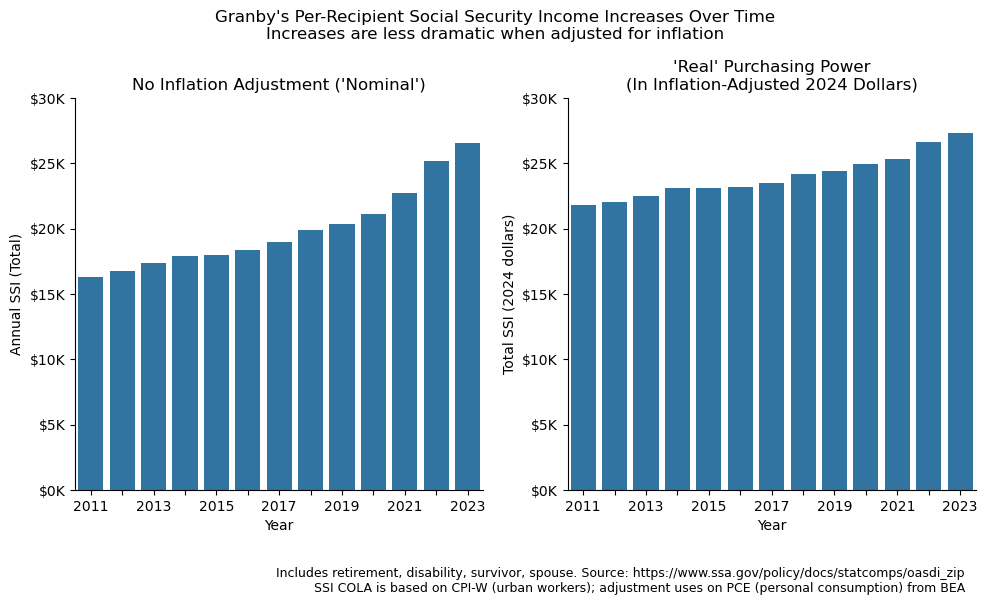

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(10,6))

line1 = "Granby's Per-Recipient Social Security Income Increases Over Time\n"
line2 = "Increases are less dramatic when adjusted for inflation"
fig.suptitle(line1 + line2)

sns.barplot(town_ssi.query('Town == "Granby"'), x='Year', y='Annual SSI (Total)',
                 ax = axs[0])
axs[0].set_title("No Inflation Adjustment ('Nominal')")


sns.barplot(town_ssi.query('Town == "Granby"'), x='Year', y='Total SSI (2024 dollars)',
                 ax = axs[1])
axs[1].set_title("'Real' Purchasing Power\n(In Inflation-Adjusted 2024 Dollars)")

for ax in axs:
    ax.set_ylim(0,30000)
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0: # Check if the index is odd (for every other)
            label.set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

line1 = "Includes retirement, disability, survivor, spouse. Source: https://www.ssa.gov/policy/docs/statcomps/oasdi_zip\n"
line2 = "SSI COLA is based on CPI-W (urban workers); adjustment uses on PCE (personal consumption) from BEA"

fig.text(.97, 0.01, line1 + line2, fontsize=9, ha='right')
sns.despine()

# already have
#plt.savefig("./charts/social_security/ssi_real_increase.png", dpi=200, metadata=png_metadata)

plt.show()

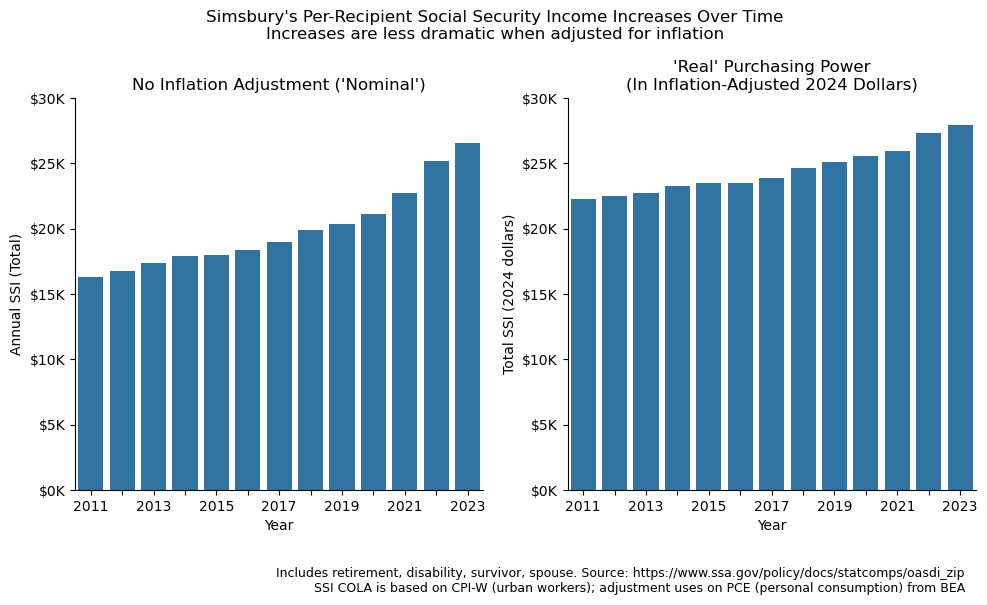

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(10,6))

line1 = "Simsbury's Per-Recipient Social Security Income Increases Over Time\n"
line2 = "Increases are less dramatic when adjusted for inflation"
fig.suptitle(line1 + line2)

sns.barplot(town_ssi.query('Town == "Granby"'), x='Year', y='Annual SSI (Total)',
                 ax = axs[0])
axs[0].set_title("No Inflation Adjustment ('Nominal')")


sns.barplot(town_ssi.query('Town == "Simsbury"'), x='Year', y='Total SSI (2024 dollars)',
                 ax = axs[1])
axs[1].set_title("'Real' Purchasing Power\n(In Inflation-Adjusted 2024 Dollars)")

for ax in axs:
    ax.set_ylim(0,30000)
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0: # Check if the index is odd (for every other)
            label.set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

line1 = "Includes retirement, disability, survivor, spouse. Source: https://www.ssa.gov/policy/docs/statcomps/oasdi_zip\n"
line2 = "SSI COLA is based on CPI-W (urban workers); adjustment uses on PCE (personal consumption) from BEA"

fig.text(.97, 0.01, line1 + line2, fontsize=9, ha='right')
sns.despine()

# already have
#plt.savefig("./charts/social_security/ssi_real_increase.png", dpi=200, metadata=png_metadata)

plt.show()

#### Retirement Income Index
This is only an index useful for comparison.

Average taxable SSI, Pensions, Annuities, Retirement Acccount distributions per "Elderly" return. 

This understates retiree income. First, it excludes other sources of taxable income, non-taxable distributions or interest, or taxable dividends or interest because those are not reported separately by the IRS. Second, because the number of elderly returns used as the denominator is larger than the number of returns reporting taxable pensions, annuities, and distributions, the resulting average is likely underestimated.

In [35]:
town_total_income.query('Town == "Granby"')[['Year', 'Number of returns', 'Number of elderly returns', 'Retirement Income Index']]\
    .style.format({'Number of returns':"{:,.0f}", 'Number of elderly returns':"{:,.0f}",'Retirement Income Index':"${:,.0f}"})

,Year,Number of returns,Number of elderly returns,Retirement Income Index
4248,2013,"5,520",0,$nan
4255,2014,"5,480",0,$nan
4262,2015,"5,520","1,640","$45,700"
4269,2016,"5,480","1,660","$46,859"
4276,2017,"5,520","1,730","$47,127"
4283,2018,"5,530","1,820","$48,384"
4290,2019,"5,660","1,880","$48,665"
4297,2020,"5,760","1,940","$44,783"
4304,2021,"5,700","2,000","$48,541"
4311,2022,"5,790","2,080","$47,723"


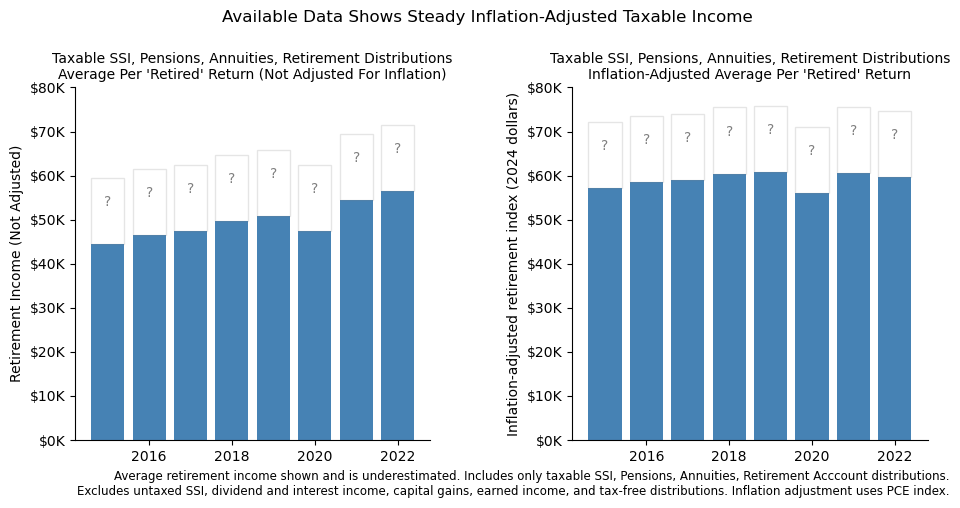

In [36]:

_df = town_total_income[town_total_income['Number of elderly returns'] > 0].query('Town == "Granby"')


fig, axs = plt.subplots(1, 2, figsize=(11,5), gridspec_kw={'wspace':.4})

fig.suptitle("Available Data Shows Steady Inflation-Adjusted Taxable Income")

# left side
ax = axs[0]

bars = ax.bar(_df['Year'],
       _df['Retirement Income Per Return'],
       facecolor='steelblue', )

for bar in bars:
    height = bar.get_height() + 7000
    ax.annotate("?",
                xy=(bar.get_x() + bar.get_width() / 2, height), #
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='gray')

ax.bar(_df['Year'],
       _df.shape[0]*[15000],
       bottom=_df['Retirement Income Per Return'],
       edgecolor='gray', facecolor='none', alpha=.2)
sns.despine()

ax.set_ylabel("Retirement Income (Not Adjusted)")
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylim(top=80000)

ax.set_title("Taxable SSI, Pensions, Annuities, Retirement Distributions\nAverage Per 'Retired' Return (Not Adjusted For Inflation)",
            fontsize=10)


# right side
ax = axs[1]

ax.set_title("Taxable SSI, Pensions, Annuities, Retirement Distributions\nInflation-Adjusted Average Per 'Retired' Return",
            fontsize=10)

_df = town_total_income[town_total_income['Number of elderly returns'] > 0].query('Town == "Granby"')

bars = ax.bar(_df['Year'],
       _df['Retirement Income Index (2024 dollars)'],
       facecolor='steelblue', )

for bar in bars:
    height = bar.get_height() + 7000
    ax.annotate("?",
                xy=(bar.get_x() + bar.get_width() / 2, height), #
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='gray')

ax.bar(_df['Year'],
       _df.shape[0]*[15000],
       bottom=_df['Retirement Income Index (2024 dollars)'],
       edgecolor='gray', facecolor='none', alpha=.2)
sns.despine()

ax.set_ylabel("Inflation-adjusted retirement index (2024 dollars)")
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylim(top=80000)

plt.subplots_adjust(top=.825, bottom=0.12)

line1 = "Average retirement income shown and is underestimated. Includes only taxable SSI, Pensions, Annuities, Retirement Acccount distributions."
line2 = "\nExcludes untaxed SSI, "
line3 = "dividend and interest income, capital gains, earned income, and tax-free distributions. Inflation adjustment uses PCE index."
fig.text(.92, .01, line1 + line2 + line3, ha='right', fontsize=8.5)

plt.savefig(f"./charts/social_security/real_retirement_index.png", dpi=200, metadata=png_metadata)

plt.show()

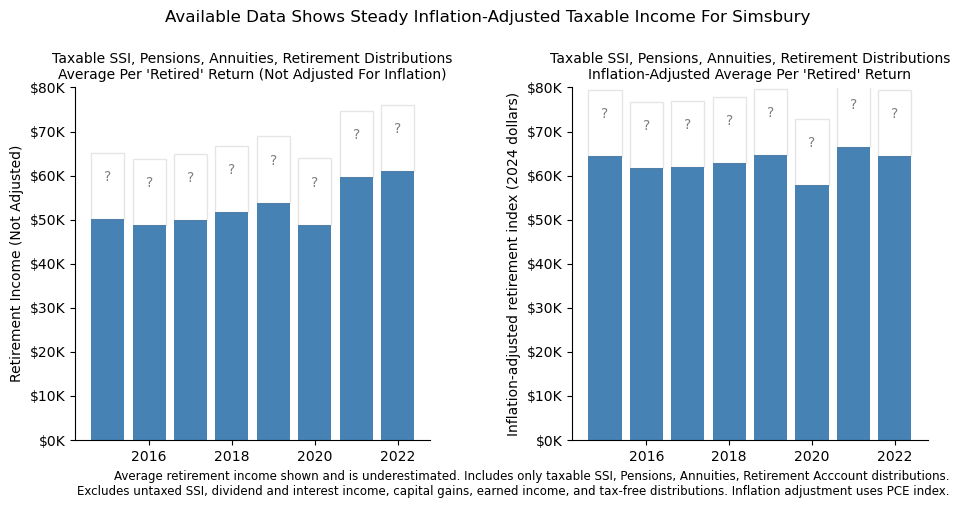

In [37]:

_df = town_total_income[town_total_income['Number of elderly returns'] > 0].query('Town == "Simsbury"')


fig, axs = plt.subplots(1, 2, figsize=(11,5), gridspec_kw={'wspace':.4})

fig.suptitle("Available Data Shows Steady Inflation-Adjusted Taxable Income For Simsbury")

# left side
ax = axs[0]

bars = ax.bar(_df['Year'],
       _df['Retirement Income Per Return'],
       facecolor='steelblue', )

for bar in bars:
    height = bar.get_height() + 7000
    ax.annotate("?",
                xy=(bar.get_x() + bar.get_width() / 2, height), #
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='gray')

ax.bar(_df['Year'],
       _df.shape[0]*[15000],
       bottom=_df['Retirement Income Per Return'],
       edgecolor='gray', facecolor='none', alpha=.2)
sns.despine()

ax.set_ylabel("Retirement Income (Not Adjusted)")
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylim(top=80000)

ax.set_title("Taxable SSI, Pensions, Annuities, Retirement Distributions\nAverage Per 'Retired' Return (Not Adjusted For Inflation)",
            fontsize=10)


# right side
ax = axs[1]

ax.set_title("Taxable SSI, Pensions, Annuities, Retirement Distributions\nInflation-Adjusted Average Per 'Retired' Return",
            fontsize=10)

_df = town_total_income[town_total_income['Number of elderly returns'] > 0].query('Town == "Simsbury"')

bars = ax.bar(_df['Year'],
       _df['Retirement Income Index (2024 dollars)'],
       facecolor='steelblue', )

for bar in bars:
    height = bar.get_height() + 7000
    ax.annotate("?",
                xy=(bar.get_x() + bar.get_width() / 2, height), #
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='gray')

ax.bar(_df['Year'],
       _df.shape[0]*[15000],
       bottom=_df['Retirement Income Index (2024 dollars)'],
       edgecolor='gray', facecolor='none', alpha=.2)
sns.despine()

ax.set_ylabel("Inflation-adjusted retirement index (2024 dollars)")
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylim(top=80000)

plt.subplots_adjust(top=.825, bottom=0.12)

line1 = "Average retirement income shown and is underestimated. Includes only taxable SSI, Pensions, Annuities, Retirement Acccount distributions."
line2 = "\nExcludes untaxed SSI, "
line3 = "dividend and interest income, capital gains, earned income, and tax-free distributions. Inflation adjustment uses PCE index."
fig.text(.92, .01, line1 + line2 + line3, ha='right', fontsize=8.5)

plt.savefig(f"./charts/social_security/real_retirement_index_simsbury.png", dpi=200, metadata=png_metadata)

plt.show()

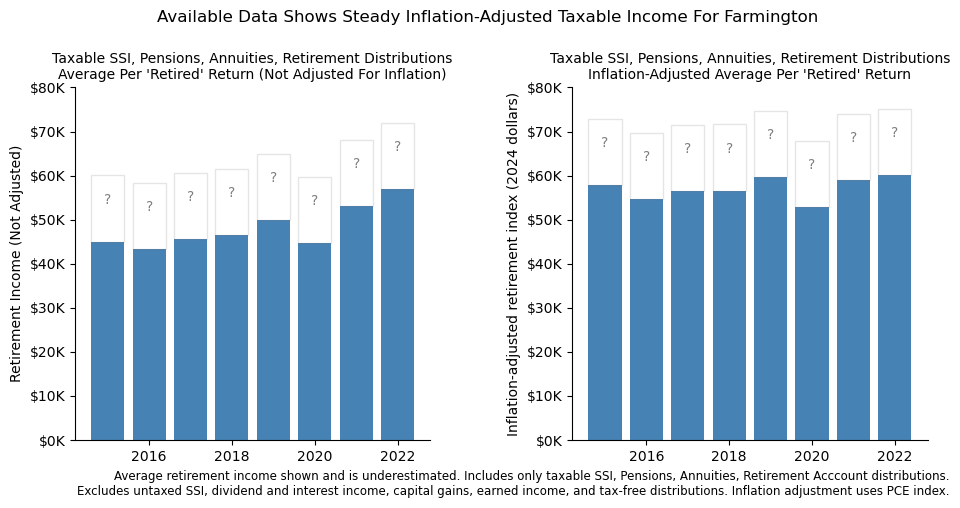

In [38]:

_df = town_total_income[town_total_income['Number of elderly returns'] > 0].query('Town == "Farmington"')


fig, axs = plt.subplots(1, 2, figsize=(11,5), gridspec_kw={'wspace':.4})

fig.suptitle("Available Data Shows Steady Inflation-Adjusted Taxable Income For Farmington")

# left side
ax = axs[0]

bars = ax.bar(_df['Year'],
       _df['Retirement Income Per Return'],
       facecolor='steelblue', )

for bar in bars:
    height = bar.get_height() + 7000
    ax.annotate("?",
                xy=(bar.get_x() + bar.get_width() / 2, height), #
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='gray')

ax.bar(_df['Year'],
       _df.shape[0]*[15000],
       bottom=_df['Retirement Income Per Return'],
       edgecolor='gray', facecolor='none', alpha=.2)
sns.despine()

ax.set_ylabel("Retirement Income (Not Adjusted)")
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylim(top=80000)

ax.set_title("Taxable SSI, Pensions, Annuities, Retirement Distributions\nAverage Per 'Retired' Return (Not Adjusted For Inflation)",
            fontsize=10)


# right side
ax = axs[1]

ax.set_title("Taxable SSI, Pensions, Annuities, Retirement Distributions\nInflation-Adjusted Average Per 'Retired' Return",
            fontsize=10)

_df = town_total_income[town_total_income['Number of elderly returns'] > 0].query('Town == "Farmington"')

bars = ax.bar(_df['Year'],
       _df['Retirement Income Index (2024 dollars)'],
       facecolor='steelblue', )

for bar in bars:
    height = bar.get_height() + 7000
    ax.annotate("?",
                xy=(bar.get_x() + bar.get_width() / 2, height), #
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', color='gray')

ax.bar(_df['Year'],
       _df.shape[0]*[15000],
       bottom=_df['Retirement Income Index (2024 dollars)'],
       edgecolor='gray', facecolor='none', alpha=.2)
sns.despine()

ax.set_ylabel("Inflation-adjusted retirement index (2024 dollars)")
ax.yaxis.set_major_formatter(dollar_k_formatter)
ax.set_ylim(top=80000)

plt.subplots_adjust(top=.825, bottom=0.12)

line1 = "Average retirement income shown and is underestimated. Includes only taxable SSI, Pensions, Annuities, Retirement Acccount distributions."
line2 = "\nExcludes untaxed SSI, "
line3 = "dividend and interest income, capital gains, earned income, and tax-free distributions. Inflation adjustment uses PCE index."
fig.text(.92, .01, line1 + line2 + line3, ha='right', fontsize=8.5)

plt.savefig(f"./charts/social_security/real_retirement_index_farmington.png", dpi=200, metadata=png_metadata)

plt.show()

### Nominal income distributions

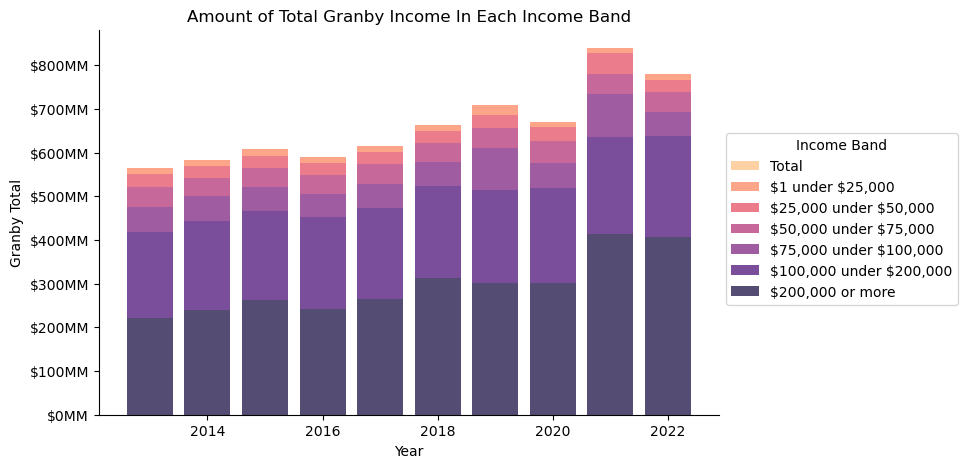

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(town_band_income[town_band_income.Town == 'Granby'],
             x="Year", weights='Total income Amount',
             palette="magma_r", discrete=True, edgecolor=None, shrink=.8,
            hue='Income Band', multiple='stack', ax=ax)

ax.yaxis.set_major_formatter(dollar_mm_formatter)

# Add labels and title
ax.set_ylabel("Granby Total")
ax.set_title("Amount of Total Granby Income In Each Income Band")

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, .75))
sns.despine()
plt.show()

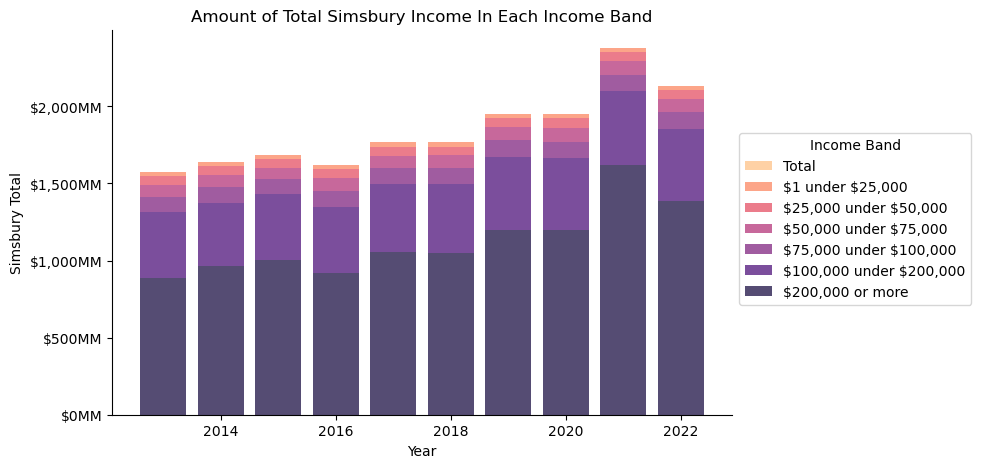

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(town_band_income[town_band_income.Town == 'Simsbury'],
             x="Year", weights='Total income Amount',
             palette="magma_r", discrete=True, edgecolor=None, shrink=.8,
            hue='Income Band', multiple='stack', ax=ax)

ax.yaxis.set_major_formatter(dollar_mm_formatter)

# Add labels and title
ax.set_ylabel("Simsbury Total")
ax.set_title("Amount of Total Simsbury Income In Each Income Band")

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, .75))
sns.despine()
plt.show()